In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def rhs_1d_wave_center(u, xmin, xmax, a):
    """
    j = 0 to N
    u[0] = 0 or another boundary condition
    u[N] = 0 or another boundary condition
    we need to look at j=1 to j=N-1
    """
    # number of grid points is the same vector size
    n = u.shape[0]
    dx = (xmax-xmin)/(n-1)
    rhs = np.zeros_like(u)
    # numpy syntax for (u[j+1]-u[j-1])/(2*dx)
    rhs[1:-1] = -(a) * (u[2:] - u[:-2])/(2.0*dx) # second order central

    return rhs


"""    
forward scheme with a < 0 or 
backward scheme with a > 0 
for advection is called upwind
"""

def rhs_1d_wave_upwind(u, xmin, xmax, a):
    # number of grid points is the same vector size
    n = u.shape[0]
    dx = (xmax-xmin)/(n-1)
    rhs = np.zeros_like(u)

    if a > 0:
        rhs[1:-1] = -(a) * (u[1:-1] - u[:-2])/(dx) # forward
    else:
        rhs[1:-1] = -(a) * (u[2:-1] - u[1:-1])/(dx) # backward
        
    return rhs

# -----------------------
# Euler explicit step
# -----------------------
def euler_step(u, dt, rhs, *rhs_args):
    return u + dt*rhs(u, *rhs_args)


# -----------------------
# RK4 step
# -----------------------
def rk4_step(u, dt, rhs, *rhs_args):
    k1 = rhs(u, *rhs_args)
    k2 = rhs(u + 0.5*dt*k1, *rhs_args)
    k3 = rhs(u + 0.5*dt*k2, *rhs_args)
    k4 = rhs(u + dt*k3, *rhs_args)
    return u + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)



CFL =  0.500000000000000 nsteps =  5096 dt =  0.0000981161695447410


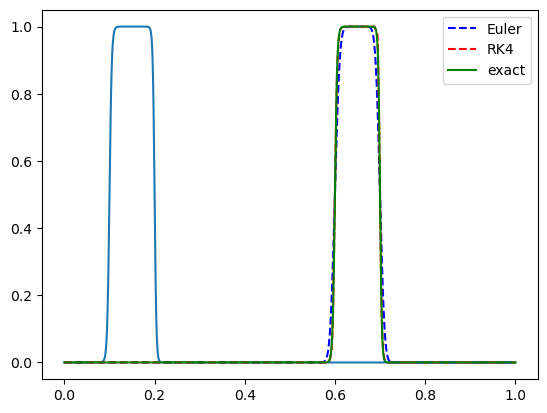

In [3]:
# -----------------------
# Grid & parameters
# -----------------------
xmin = 0.0
xmax = 1.0          # domain length
nx   = 5096          # grid points
dx   = (xmax-xmin)/nx

# generate grid
x = np.linspace(xmin, xmax, nx)
a    = 1.0          # advection speed c

CFL  = 0.5
dt  = CFL * dx / abs(a)
T   = 0.5
nsteps = int(np.ceil(T/dt)); # total number of time step

print('CFL = ', a*dt/(dx), 'nsteps = ', nsteps, 'dt = ', dt)

# initial solution
exact = 0.5*(np.tanh((x-0.6)/5e-3) - np.tanh((x-0.7)/4e-3))
u = 0.5*(np.tanh((x-0.1)/5e-3) - np.tanh((x-0.2)/4e-3))
v = u
plt.plot(x,u)

for _ in range(nsteps):

    v = euler_step(v, dt, rhs_1d_wave_upwind, xmin, xmax, a)
    u = rk4_step(u, dt, rhs_1d_wave_center, xmin, xmax, a)

plt.plot(x,v,'b--', label='Euler')
plt.plot(x,u,'r--', label='RK4')
plt.plot(x,exact, 'g-',label='exact')

plt.legend()


CFL =  0.950000000000000 nsteps =  1078


((108, 2048), (108,))

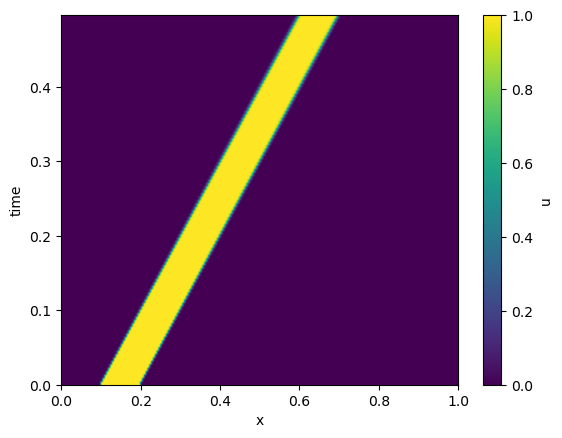

In [4]:
# -----------------------
# Grid & parameters
# -----------------------
xmin = 0.0
xmax = 1.0          # domain length
nx   = 2048          # grid points
dx   = (xmax-xmin)/nx

# generate grid
x = np.linspace(xmin, xmax, nx)
a    = 1.0          # advection speed c

CFL  = 0.95
dt  = CFL * dx / abs(a)
T   = 0.5
nsteps = int(np.ceil(T/dt)); 

print('CFL = ', a*dt/(dx), 'nsteps = ', nsteps)

# initial solution
u = 0.5*(np.tanh((x-0.1)/2e-3) - np.tanh((x-0.2)/2e-3))
v = u

m  = 10                         # save every m-th step
nsnaps = nsteps // m + 1        # +1 for t=0
sol   = np.zeros((nsnaps, nx))
times = np.zeros(nsnaps)

# save initial
sol[0]   = u.copy()
times[0] = 0.0

# start iteration
k = 1
t = 0.0
for n in range(1, nsteps+1):

    v = euler_step(v, dt, rhs_1d_wave_upwind, xmin, xmax, a)
    u = rk4_step(u, dt, rhs_1d_wave_center, xmin, xmax, a)

    t += dt
    if n % m == 0:
        sol[k] = v
        times[k] = t
        k += 1

plt.imshow(sol, aspect='auto', origin='lower',
           extent=[x.min(), x.max(), times[0], times[-1]])
plt.xlabel('x'); plt.ylabel('time'); plt.colorbar(label='u')
sol.shape, times.shape